# Week 6 — Building and Learning a Bayesian Network with an LLM Coding Assistant

**CS F407 Artificial Intelligence · Lab 6** · Lab notebook: [`llm_bn.ipynb`](../lab-question/llm_bn.ipynb)

The lab keeps one Bayesian network throughout, the Sprinkler network, $C \to R,\ C \to S,\ R,S \to W$. It asks a coding LLM to turn natural-language specifications into `pgmpy` code for three tasks: **exact inference**, **maximum-likelihood estimation**, and **Bayesian (BDeu) estimation**. Each generated program must then be **inspected, executed, and validated**. The lab ends with three exercises: changing the query, explaining a CPT, and estimating from different datasets.

In the lab notebook the generated code was *never run*: every approval flag was left at `False`. This solution runs every generated program behind a safety check, validates it against a trusted model, iterates on the prompts, and completes all three exercises.

**Which LLM answered what:**
- **The lab's model, Qwen2.5-Coder-1.5B-Instruct:** used for the main workflow (all three tasks, the feedback rounds, the CPT explanation, and the first query).
- **Qwen2.5-Coder-32B-Instruct:** a model-size comparison, and the query and sampling-variability exercises.
- **Qwen3-Coder-30B-A3B-Instruct:** a model-size comparison.

Every response is labelled with the model that produced it.

All requests use the lab's system prompt and temperature 0 (greedy decoding, the equivalent of the lab's `do_sample=False`). Every response is saved in [`outputs/llm_responses.json`](outputs/llm_responses.json), and the notebook analyses exactly those saved responses.

| Section | Contents |
|---|---|
| 1–2 | Trusted reference model, enumeration oracle, semantic validators |
| 3 | LLM client, response cache, reproducibility check against the lab's own recorded outputs |
| 4 | Code-safety tooling, and a gap found in the lab's AST check |
| 5 | Task 1 — inference: three prompting rounds, then a minimal human fix |
| 6 | Task 2 — MLE parameter estimation |
| 7 | Task 3 — Bayesian (BDeu) estimation |
| 8 | Does a bigger model fix it? 1.5B vs 32B vs Qwen3-30B |
| 9 | HW exercise — change the query (predict, generate, inspect, compare) |
| 10 | Exercise — let the LLM explain the WetGrass CPT |
| 11 | Exercise — estimates from different datasets (sampling variability) |
| 12 | The lab's model run locally: same prompts, same checks |
| 13 | Failure modes observed, rubric scorecard, what the LLM contributed |

In [1]:
import warnings
warnings.filterwarnings("ignore")                  # pgmpy deprecation and tqdm notices (deprecations are discussed where relevant)

import ast
import difflib
import hashlib
import importlib
import itertools
import json
import os
import pathlib
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.parameter_estimator import DiscreteMLE, DiscreteBayesianEstimator

OUT_DIR = pathlib.Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
np.random.seed(7)
print("pgmpy", pgmpy.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

pgmpy 1.1.2 | pandas 3.0.6 | numpy 2.5.3


## 1. The trusted specification and reference model

This is the same model the lab builds by hand: $P(C,R,S,W) = P(C)\,P(R\mid C)\,P(S\mid C)\,P(W\mid R,S)$ with the lab's parameters. It is written independently here, and checked against a brute-force enumeration of all 16 assignments before anything else relies on it.

In [2]:
EDGES = [("Cloudy", "Rain"), ("Cloudy", "Sprinkler"), ("Rain", "WetGrass"), ("Sprinkler", "WetGrass")]
VARS = ["Cloudy", "Rain", "Sprinkler", "WetGrass"]

# The specification, as P(X=1 | parents) -- the form in which the lab states it.
SPEC_P_TRUE = {
    "Cloudy":    {(): 0.5},
    "Rain":      {(0,): 0.2, (1,): 0.8},
    "Sprinkler": {(0,): 0.5, (1,): 0.1},
    "WetGrass":  {(0, 0): 0.01, (0, 1): 0.90, (1, 0): 0.90, (1, 1): 0.99},
}
PARENTS = {"Cloudy": [], "Rain": ["Cloudy"], "Sprinkler": ["Cloudy"], "WetGrass": ["Rain", "Sprinkler"]}


def build_reference_model():
    model = DiscreteBayesianNetwork(EDGES)
    for var, table in SPEC_P_TRUE.items():
        p_true = [table[key] for key in sorted(table)]            # parent combos in pgmpy column order
        values = [[1 - p for p in p_true], p_true]                # row 0 = state 0, row 1 = state 1
        parents = PARENTS[var]
        model.add_cpds(TabularCPD(var, 2, values, evidence=parents or None, evidence_card=[2] * len(parents) or None))
    assert model.check_model()
    return model


def spec_joint(assignment):
    # The specification's joint probability, computed directly from SPEC_P_TRUE (no pgmpy involved).
    p = 1.0
    for var in VARS:
        p1 = SPEC_P_TRUE[var][tuple(assignment[q] for q in PARENTS[var])]
        p *= p1 if assignment[var] == 1 else 1 - p1
    return p


def enumerate_posterior(query_var, evidence):
    # P(query_var = 1 | evidence) by brute-force summation over all 2^4 assignments.
    num = den = 0.0
    for values in itertools.product([0, 1], repeat=4):
        a = dict(zip(VARS, values))
        if all(a[k] == v for k, v in evidence.items()):
            p = spec_joint(a)
            den += p
            num += p if a[query_var] == 1 else 0.0
    return num / den


reference_model = build_reference_model()
reference_infer = VariableElimination(reference_model)
for cpd in reference_model.get_cpds():
    print(cpd, "\n")

+-----------+-----+
| Cloudy(0) | 0.5 |
+-----------+-----+
| Cloudy(1) | 0.5 |
+-----------+-----+ 

+---------+-----------+---------------------+
| Cloudy  | Cloudy(0) | Cloudy(1)           |
+---------+-----------+---------------------+
| Rain(0) | 0.8       | 0.19999999999999996 |
+---------+-----------+---------------------+
| Rain(1) | 0.2       | 0.8                 |
+---------+-----------+---------------------+ 

+--------------+-----------+-----------+
| Cloudy       | Cloudy(0) | Cloudy(1) |
+--------------+-----------+-----------+
| Sprinkler(0) | 0.5       | 0.9       |
+--------------+-----------+-----------+
| Sprinkler(1) | 0.5       | 0.1       |
+--------------+-----------+-----------+ 

+-------------+--------------+-----+----------------------+
| Rain        | Rain(0)      | ... | Rain(1)              |
+-------------+--------------+-----+----------------------+
| Sprinkler   | Sprinkler(0) | ... | Sprinkler(1)         |
+-------------+--------------+-----+---------

In [3]:
def model_joint(model, assignment):
    # Joint probability encoded by a pgmpy model, read through TabularCPD.get_value (order-independent).
    p = 1.0
    for cpd in model.get_cpds():
        p *= float(cpd.get_value(**{v: assignment[v] for v in cpd.variables}))
    return p


def joint_max_error(model):
    # Largest |P_model(x) - P_spec(x)| over all 16 assignments: the strongest semantic test.
    return max(abs(model_joint(model, dict(zip(VARS, v))) - spec_joint(dict(zip(VARS, v))))
               for v in itertools.product([0, 1], repeat=4))


def wrong_entries(model, tol=1e-9):
    # Which CPT entries P(X=1 | parents) disagree with the specification.
    out = []
    for var in VARS:
        cpd = model.get_cpds(var)
        for key, p1 in SPEC_P_TRUE[var].items():
            got = float(cpd.get_value(**{var: 1, **dict(zip(PARENTS[var], key))}))
            if abs(got - p1) > tol:
                cond = ", ".join(f"{q}={k}" for q, k in zip(PARENTS[var], key))
                out.append(f"P({var}=1{' | ' + cond if cond else ''}) = {got:g} (spec {p1:g})")
    return out


# The reference model must match the specification exactly.
reference_posterior = reference_infer.query(["Rain"], evidence={"WetGrass": 1}, show_progress=False)
print("joint max error of reference model:", joint_max_error(reference_model))
print("P(Rain=1 | WetGrass=1): pgmpy =", reference_posterior.values[1], " enumeration =", enumerate_posterior("Rain", {"WetGrass": 1}))
assert joint_max_error(reference_model) < 1e-12
assert np.isclose(reference_posterior.values[1], enumerate_posterior("Rain", {"WetGrass": 1}))

joint max error of reference model: 0.0
P(Rain=1 | WetGrass=1): pgmpy = 0.7047692307692307  enumeration = 0.7047692307692309


## 2. Trusted parameter-estimation references

These are the lab's own fitting calls (`DiscreteMLE`, `DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=10)`) on the lab's dataset ($N = 1000$, seed 7). Every LLM-generated fit is compared with them, **entry by entry through `get_value`**, rather than by raw array position. A generated model that lists WetGrass's parents in a different order would have its columns permuted, and comparing arrays position by position would then report a spurious mismatch, or even hide a real one.

In [4]:
data_1000 = reference_model.simulate(n_samples=1000, seed=7, show_progress=False)

def fit(estimator, data):
    m = DiscreteBayesianNetwork(EDGES)
    m.fit(data, estimator=estimator)
    assert m.check_model()
    return m

trusted_mle = fit(DiscreteMLE(), data_1000)
trusted_bdeu = fit(DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=10), data_1000)

def cpd_max_diff(model_a, model_b):
    # Max |P_a(X=x | pa) - P_b(X=x | pa)| over every CPT entry, compared by variable name and state.
    worst = 0.0
    for var in VARS:
        a, b = model_a.get_cpds(var), model_b.get_cpds(var)
        for vals in itertools.product([0, 1], repeat=1 + len(PARENTS[var])):
            kw = dict(zip([var] + PARENTS[var], vals))
            worst = max(worst, abs(float(a.get_value(**kw)) - float(b.get_value(**kw))))
    return worst

print("trusted MLE   P(Rain=1 | Cloudy=1) =", float(trusted_mle.get_cpds("Rain").get_value(Rain=1, Cloudy=1)))
print("trusted BDeu  P(Rain=1 | Cloudy=1) =", float(trusted_bdeu.get_cpds("Rain").get_value(Rain=1, Cloudy=1)))

trusted MLE   P(Rain=1 | Cloudy=1) = 0.7725409836065574
trusted BDeu  P(Rain=1 | Cloudy=1) = 0.7697768762677485


## 3. The LLM client

Each prompt goes to the named model with the lab's system prompt at temperature 0. [`llm_client.py`](llm_client.py) sends the request and saves the response. The notebook works only from the saved responses.

In [5]:
from llm_client import SYSTEM, cache_key, make_ask

MAIN_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"        # the lab's model
LARGE_MODEL = "Qwen/Qwen2.5-Coder-32B-Instruct"
COMPARISON_MODELS = [MAIN_MODEL, LARGE_MODEL, "Qwen/Qwen3-Coder-30B-A3B-Instruct"]
CACHE_PATH = OUT_DIR / "llm_responses.json"
ask = make_ask(CACHE_PATH)
print("system prompt:", SYSTEM)

def ask_coder(prompt, model=MAIN_MODEL):
    response = ask(prompt, model)
    print(f"[{model}]\n")
    return response

cache = json.loads(CACHE_PATH.read_text())
print(f"{len(cache)} cached responses:", dict(pd.Series([v['model'] for v in cache.values()]).value_counts()))

system prompt: You are an expert Python programmer working with discrete Bayesian networks and the current pgmpy API. Follow the user specification exactly. Return concise executable code when code is requested.
20 cached responses: {'Qwen/Qwen2.5-Coder-1.5B-Instruct': np.int64(9), 'Qwen/Qwen2.5-Coder-32B-Instruct': np.int64(8), 'Qwen/Qwen3-Coder-30B-A3B-Instruct': np.int64(3)}


### Reproducibility check against the lab's own recorded outputs

The lab notebook contains the responses that Qwen2.5-Coder-1.5B gave *when the lab was run locally* with `do_sample=False`. The cells below send the same prompts to the same model again and compare the answers.

In [6]:
INFERENCE_PROMPT = r"""
Write Python code using the current pgmpy API.

Construct this binary discrete Bayesian network:

Edges:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Use states 0=False and 1=True.

Probabilities:
P(Cloudy=1) = 0.5

P(Rain=1 | Cloudy=0) = 0.2
P(Rain=1 | Cloudy=1) = 0.8

P(Sprinkler=1 | Cloudy=0) = 0.5
P(Sprinkler=1 | Cloudy=1) = 0.1

P(WetGrass=1 | Rain=0, Sprinkler=0) = 0.01
P(WetGrass=1 | Rain=0, Sprinkler=1) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=0) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=1) = 0.99

Requirements:
- use DiscreteBayesianNetwork and TabularCPD;
- create a variable called generated_model;
- add all CPDs;
- call generated_model.check_model();
- use VariableElimination;
- compute P(Rain | WetGrass=1);
- store that query result in generated_posterior;
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

ESTIMATION_PROMPT = r"""
Write Python code using the current pgmpy API.

A pandas DataFrame named data already exists. Its columns are:
Cloudy, Rain, Sprinkler, WetGrass.
All variables use binary states 0 and 1.

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

The CPT parameters are unknown.

Requirements:
- use DiscreteBayesianNetwork;
- use MaximumLikelihoodEstimator;
- estimate all CPTs from data while keeping the graph fixed;
- store the fitted model in a variable called generated_mle_model;
- call generated_mle_model.check_model();
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

BAYESIAN_PROMPT = r"""
A pandas DataFrame named data already exists with binary columns:
Cloudy, Rain, Sprinkler, WetGrass.

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Write Python code using the current pgmpy API to estimate all CPTs with BayesianEstimator.
Use:
prior_type="BDeu"
equivalent_sample_size=10

Requirements:
- keep the graph fixed;
- store the fitted model in generated_bayes_model;
- call generated_bayes_model.check_model();
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

# The lab notebook's recorded (local, do_sample=False) responses, read straight from the lab file.
lab_nb = json.loads(pathlib.Path("../lab-question/llm_bn.ipynb").read_text())
def recorded_response(prompt_var):
    for c in lab_nb["cells"]:
        if c["cell_type"] == "code" and f"ask_coder({prompt_var})" in "".join(c["source"]):
            return "".join("".join(o.get("text", "")) for o in c["outputs"] if o.get("name") == "stdout")
lab_recorded = {name: recorded_response(var) for name, var in
                [("inference", "inference_prompt"), ("estimation", "estimation_prompt"), ("bayesian", "bayesian_prompt")]}
api_round1 = {"inference": ask(INFERENCE_PROMPT, MAIN_MODEL), "estimation": ask(ESTIMATION_PROMPT, MAIN_MODEL),
              "bayesian": ask(BAYESIAN_PROMPT, MAIN_MODEL)}
for name in api_round1:
    same = lab_recorded[name].strip() == api_round1[name].strip()
    print(f"{name:<11} new response identical to the lab's recorded response: {same}")

inference   new response identical to the lab's recorded response: False
estimation  new response identical to the lab's recorded response: False
bayesian    new response identical to the lab's recorded response: False


**None of the three responses matches the lab's recorded one,** even though the model, the prompt, the system prompt and greedy decoding are all the same. Repeated requests during development also varied. One earlier inference response *was* identical to the lab's, and the estimation prompt produced three different programs across runs.

Greedy decoding is only deterministic for a fixed implementation. A different runtime (hardware, batching, kernels, numeric precision) changes the floating-point arithmetic slightly. When two candidate next tokens are nearly tied, that small difference is enough to flip the choice, and the rest of the generation diverges from there. **An LLM-generated program must therefore be saved as an artifact:** "re-run the prompt" is not a reproducible build step. That is why every response is saved here, and why the lab's recorded responses are analysed alongside the new ones.

## 4. Code-safety tooling

The lab's `basic_generated_code_check` rejects some obviously dangerous constructs before `exec`. It is kept below unchanged, with a stricter check added alongside it.

In [7]:
def extract_python_code(text):
    match = re.search(r"```(?:python)?\s*(.*?)```", text.strip(), flags=re.DOTALL)
    return match.group(1).strip() if match else text.strip()


# --- the lab's check, unchanged ---
ALLOWED_IMPORT_PREFIXES = ("pgmpy", "numpy", "pandas")
FORBIDDEN_CALL_NAMES = {"eval", "exec", "compile", "open", "input", "__import__"}

def basic_generated_code_check(source):
    tree = ast.parse(source)
    problems = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                if not alias.name.startswith(ALLOWED_IMPORT_PREFIXES):
                    problems.append(f"Import not allowed: {alias.name}")
        if isinstance(node, ast.ImportFrom):
            module = node.module or ""
            if not module.startswith(ALLOWED_IMPORT_PREFIXES):
                problems.append(f"Import not allowed: {module}")
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name):
            if node.func.id in FORBIDDEN_CALL_NAMES:
                problems.append(f"Forbidden call: {node.func.id}")
    return problems


# --- a stricter check: attribute calls, overwritten inputs, and APIs that do not exist in the installed pgmpy ---
FORBIDDEN_ATTRIBUTE_CALLS = {"read_csv", "read_excel", "read_json", "read_parquet", "read_pickle", "read_sql",
                             "to_csv", "to_excel", "to_json", "to_pickle", "system", "popen", "remove", "unlink",
                             "rmdir", "urlopen", "get", "post"}

def strict_generated_code_check(source, provided_inputs=()):
    problems = basic_generated_code_check(source)
    tree = ast.parse(source)
    for node in ast.walk(tree):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Attribute):
            if node.func.attr in FORBIDDEN_ATTRIBUTE_CALLS and not (node.func.attr == "get" and not node.args):
                problems.append(f"Forbidden attribute call: .{node.func.attr}(...)")
        if isinstance(node, ast.Assign):
            for target in node.targets:
                if isinstance(target, ast.Name) and target.id in provided_inputs:
                    problems.append(f"Overwrites the provided input `{target.id}`")
        if isinstance(node, ast.ImportFrom) and (node.module or "").startswith("pgmpy"):
            for alias in node.names:
                try:
                    mod = importlib.import_module(node.module)
                    if not hasattr(mod, alias.name):
                        problems.append(f"API not in installed pgmpy {pgmpy.__version__}: {node.module}.{alias.name}")
                except ImportError:
                    problems.append(f"Module not in installed pgmpy: {node.module}")
    return problems


def run_generated(source, namespace):
    # Execute generated code in its own namespace; report the first exception instead of crashing the notebook.
    try:
        exec(source, namespace)
        return "ran without error"
    except Exception as e:
        message = re.sub(r"\s*\(/[^)]*\)", "", str(e).splitlines()[0])      # drop local file paths from messages
        return f"{type(e).__name__}: {message[:160]}"

**A gap in the lab's check.** It only inspects calls of the form `name(...)` (`ast.Name`). A method call such as `pd.read_csv(...)` is an `ast.Attribute` call, so it passes unnoticed. The lab's own recorded Bayesian response contains exactly that, a file read the prompt explicitly forbade, and the lab's check printed "no listed problems":

In [8]:
lab_bayes_code = extract_python_code(lab_recorded["bayesian"])
print(lab_bayes_code, "\n")
print("lab check   :", basic_generated_code_check(lab_bayes_code) or "no listed problems")
print("strict check:", strict_generated_code_check(lab_bayes_code, provided_inputs={"data"}))

from pgmpy.estimators import BayesianEstimator
import pandas as pd

# Load your data into a pandas DataFrame
data = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your actual file path

# Create a BayesianEstimator object
estimator = BayesianEstimator(data, ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Fit the model with BDeu prior and equivalent sample size of 10
generated_bayes_model = estimator.fit(prior_type="BDeu", equivalent_sample_size=10)

# Check if the model is valid
generated_bayes_model.check_model() 

lab check   : no listed problems
strict check: ['Overwrites the provided input `data`', 'Forbidden attribute call: .read_csv(...)']


The strict check adds three things: forbidden *attribute* calls (file and network I/O, `os.system`), assignments that overwrite a provided input such as `data`, and imports of names that **do not exist in the installed pgmpy**. That last one is a cheap way to catch obsolete APIs before running anything. Like the lab's check, it is **not a sandbox**. It narrows what gets executed, and it is paired with reading the code first.

All generated code in this notebook was read before being executed. It is executed only when the strict check finds no *safety* problem, meaning no file, network or system access. API-existence problems are allowed through on purpose, so that the actual failure is observed and recorded.

In [9]:
SAFETY_MARKERS = ("Forbidden", "Import not allowed")

def review_and_run(response, namespace, provided_inputs=()):
    source = extract_python_code(response)
    problems = strict_generated_code_check(source, provided_inputs)
    print(source, "\n")
    print("strict check:", problems or "no problems found")
    safety = [p for p in problems if p.startswith(SAFETY_MARKERS)]
    outcome = "NOT EXECUTED (safety check failed)" if safety else run_generated(source, namespace)
    print("execution   :", outcome)
    return source, problems, outcome

## 5. Task 1 — Inference: generate, inspect, execute, validate

### Round 1: the lab's prompt, verbatim

In [10]:
ns_inf1 = {}
src_inf1, problems_inf1, outcome_inf1 = review_and_run(api_round1["inference"], ns_inf1)

from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# Create a Bayesian Network
generated_model = BayesianNetwork()

# Define the edges
generated_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Define the CPDs
cloudy_cpd = TabularCPD('Cloudy', 2, [[0.5], [0.5]])
rain_cpd = TabularCPD('Rain', 2, [[0.2, 0.8], [0.8, 0.2]])
sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]])
wet_grass_cpd = TabularCPD('WetGrass', 2, [[0.01, 0.90, 0.90, 0.99], [0.99, 0.01, 0.10, 0.01]])

# Add the CPDs to the model
generated_model.add_cpds(cloudy_cpd, rain_cpd, sprinkler_cpd, wet_grass_cpd)

# Check the model
generated_model.check_model()

# Perform Variable Elimination
query = generated_model.query(variables=['Rain'], evidence={'WetGrass': 1})
generated_posterior = query['Rain']

print(generated_posterior) 

strict check: no problems found
execution   : ImportError: `BayesianNetwork`

**Inspection, before and after running.** The program fails at its first statement that uses the model class. But reading it shows that it would have been wrong even with a working class:

| # | Problem | Why it matters |
|---|---|---|
| 1 | `from pgmpy.models import BayesianNetwork` | removed from pgmpy (**obsolete API**). The name survives only as a stub that raises `ImportError` when used, which is why the strict check's API-existence test did not flag it. |
| 2 | Rain, Sprinkler and WetGrass CPDs have **no `evidence=`** | their parents are never declared, so the CPDs do not describe $P(R\mid C)$, $P(S\mid C)$ or $P(W\mid R,S)$ at all |
| 3 | Rain: `[[0.2, 0.8], [0.8, 0.2]]` | rows reversed: it encodes $P(R=1\mid C=0) = 0.8$, the opposite of the specification |
| 4 | Sprinkler: `[[0.5, 0.1], [0.1, 0.5]]` | columns sum to 0.6: not a distribution |
| 5 | WetGrass: `[[0.01, 0.90, 0.90, 0.99], [0.99, 0.01, 0.10, 0.01]]` | rows swapped, and garbled (one column sums to 0.91) |
| 6 | `generated_model.query(...)` | no such method; the prompt required `VariableElimination(model).query(...)` |
| 7 | `query['Rain']` | indexes the result as if it were a dict |

Seven defects in one short program. Only the edge list and the Cloudy CPT are right.

### Round 2: feed the observed failures back

The second prompt states each failure concretely, as test results: the `ImportError`, the missing method, and the exact `TabularCPD` row and column convention.

In [11]:
INFERENCE_FEEDBACK_PROMPT = r'''
Your previous code for this task failed. Problems found by testing:
1. `from pgmpy.models import BayesianModel` raises ImportError: BayesianModel was removed from pgmpy. Use `from pgmpy.models import DiscreteBayesianNetwork`.
2. `generated_model.query(...)` does not exist. Use `from pgmpy.inference import VariableElimination` and `VariableElimination(generated_model).query(variables=["Rain"], evidence={"WetGrass": 1})`. The query returns a factor; store the factor itself in generated_posterior.
3. The CPT values were wrong. In TabularCPD, `values` has one ROW per state of the variable (row 0 = state 0 = False, row 1 = state 1 = True) and one COLUMN per combination of parent states. With evidence=["Rain", "Sprinkler"] the columns are ordered (Rain=0,Sprinkler=0), (Rain=0,Sprinkler=1), (Rain=1,Sprinkler=0), (Rain=1,Sprinkler=1). Each column must sum to 1. evidence_card must have one entry per evidence variable.

Write corrected Python code using the current pgmpy API.

Construct this binary discrete Bayesian network:
Edges: Cloudy -> Rain, Cloudy -> Sprinkler, Rain -> WetGrass, Sprinkler -> WetGrass
States: 0=False, 1=True.

Probabilities:
P(Cloudy=1) = 0.5
P(Rain=1 | Cloudy=0) = 0.2
P(Rain=1 | Cloudy=1) = 0.8
P(Sprinkler=1 | Cloudy=0) = 0.5
P(Sprinkler=1 | Cloudy=1) = 0.1
P(WetGrass=1 | Rain=0, Sprinkler=0) = 0.01
P(WetGrass=1 | Rain=0, Sprinkler=1) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=0) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=1) = 0.99

Requirements:
- use DiscreteBayesianNetwork and TabularCPD;
- create a variable called generated_model;
- add all CPDs;
- call generated_model.check_model();
- use VariableElimination;
- compute P(Rain | WetGrass=1) and store the query result in generated_posterior;
- do not install packages, read or write files, or use network access;
- return only Python code.
'''

ns_inf2 = {}
response_inf2 = ask_coder(INFERENCE_FEEDBACK_PROMPT)
src_inf2, problems_inf2, outcome_inf2 = review_and_run(response_inf2, ns_inf2)

[Qwen/Qwen2.5-Coder-1.5B-Instruct]

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# Create the Bayesian Network
generated_model = DiscreteBayesianNetwork()

# Define the CPDs
cloudy_cpd = TabularCPD('Cloudy', 2, [[0.5], [0.5]])
rain_cpd = TabularCPD('Rain', 2, [[0.2, 0.8], [0.8, 0.2]])
sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]])
wet_grass_cpd = TabularCPD('WetGrass', 2, [[0.01, 0.90, 0.90, 0.99], [0.99, 0.01, 0.10, 0.01]])

# Add the CPDs to the model
generated_model.add_cpds(cloudy_cpd, rain_cpd, sprinkler_cpd, wet_grass_cpd)

# Check the model
generated_model.check_model()

# Use VariableElimination to compute P(Rain | WetGrass=1)
variable_elimination = VariableElimination(generated_model)
generated_posterior = variable_elimination.query(variables=["Rain"], evidence={"WetGrass": 1})

# Print the query result
print(generated_posterior) 

strict check: no problems found
execution   : AttributeError: 'list' objec

**Round 2 fixed the class name and the query, and broke the graph.**
- **Fixed:** it now uses `DiscreteBayesianNetwork` and stores a `VariableElimination` query in `generated_posterior`.
- **Broken:** it creates `DiscreteBayesianNetwork()` with **no edges at all**. The round-1 edge list was dropped.
- **Unchanged:**
  - `VariableElimination` is still **used but never imported**;
  - the CPDs still declare **no parents**;
  - **every CPT value is exactly as in round 1**, despite the explicit row/column explanation in the feedback.

Execution fails at the Rain CPD with `AttributeError: 'list' object has no attribute 'shape'`. That message comes from inside `pgmpy` and **misdescribes the problem**: the real error is a 2 × 2 table for a CPD with no declared parent. Library error messages are evidence, but they still have to be interpreted.

### Round 3: give it a construction template

In [12]:
INFERENCE_TEMPLATE_PROMPT = r'''
Your second attempt still failed:
1. NameError: VariableElimination was used but never imported. Add `from pgmpy.inference import VariableElimination`.
2. check_model() raised ValueError because CPT columns do not sum to 1. For example your Rain CPD [[0.2, 0.8], [0.1, 0.9]] has columns summing to 0.3 and 1.7.
3. The WetGrass CPD used evidence_card=[2], but it has two parents, so it needs evidence_card=[2, 2].

To avoid ordering mistakes, build every CPD from the probability of state 1 using exactly this pattern:

p_true = [p for column 1, p for column 2, ...]      # P(X=1 | parents) for each parent combination
values = [[1 - p for p in p_true], p_true]           # row 0 = P(X=0 | ...), row 1 = P(X=1 | ...)

The parent combinations for Rain and Sprinkler are ordered Cloudy=0, Cloudy=1.
The parent combinations for WetGrass with evidence=["Rain", "Sprinkler"] are ordered
(Rain=0,Sprinkler=0), (Rain=0,Sprinkler=1), (Rain=1,Sprinkler=0), (Rain=1,Sprinkler=1).

So:
Cloudy:    p_true = [0.5]
Rain:      p_true = [0.2, 0.8]
Sprinkler: p_true = [0.5, 0.1]
WetGrass:  p_true = [0.01, 0.90, 0.90, 0.99]

Write the complete corrected program: build the network (edges Cloudy->Rain, Cloudy->Sprinkler, Rain->WetGrass, Sprinkler->WetGrass) as generated_model with DiscreteBayesianNetwork and TabularCPD, add all CPDs, call generated_model.check_model(), and store VariableElimination(generated_model).query(variables=["Rain"], evidence={"WetGrass": 1}) in generated_posterior. Include all imports. Do not install packages, read or write files, or use the network. Return only Python code.
'''

ns_inf3 = {}
response_inf3 = ask_coder(INFERENCE_TEMPLATE_PROMPT)
src_inf3, problems_inf3, outcome_inf3 = review_and_run(response_inf3, ns_inf3)

[Qwen/Qwen2.5-Coder-1.5B-Instruct]

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# Define the probability tables for each variable
p_true = [0.5, 0.2, 0.5, 0.1]
values = [[1 - p for p in p_true], p_true]

# Create the DiscreteBayesianNetwork
generated_model = DiscreteBayesianNetwork()

# Add the edges
generated_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Add the TabularCPD for each variable
generated_model.add_cpds(
    TabularCPD('Cloudy', 2, [[0.5], [0.5]]),
    TabularCPD('Rain', 2, values),
    TabularCPD('Sprinkler', 2, values),
    TabularCPD('WetGrass', 2, [[0.01, 0.90, 0.90, 0.99], [0.99, 0.01, 0.01, 0.99]])
)

# Check the model
generated_model.check_model()

# Perform variable elimination
generated_posterior = generated_model.query(variables=["Rain"], evidence={"WetGrass": 1})

# Print the result
print(generated_posterior) 

strict check: no problems f

**Round 3 regressed.** Given a mechanical construction pattern, the model copied it at the level of text. It merged four unrelated numbers into one list, `p_true = [0.5, 0.2, 0.5, 0.1]` (Cloudy, Rain and Sprinkler values mixed together), and then used the **same** `values` for both Rain and Sprinkler. The CPDs still declare no parents, WetGrass gets a new invented table, and the code is back to the nonexistent `generated_model.query(...)`. More specific instructions did not help a 1.5B model: it matched the surface form of the hint without its meaning.

### Human fix: take the best attempt (round 2) and make minimal, justified edits

After three rounds, the engineering decision is to stop prompting and fix the program by hand. Round 2 is the best starting point, because it has the right model class and the right query. Each edit targets one defect found above, and the diff shows exactly what was changed:

In [13]:
EDITS = [
    # (defect, LLM line, corrected line)
    ("missing import",
     "from pgmpy.factors.discrete import TabularCPD",
     "from pgmpy.factors.discrete import TabularCPD\nfrom pgmpy.inference import VariableElimination"),
    ("graph has no edges",
     "generated_model = DiscreteBayesianNetwork()",
     "generated_model = DiscreteBayesianNetwork([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])"),
    ("Rain: rows reversed, parent missing",
     "rain_cpd = TabularCPD('Rain', 2, [[0.2, 0.8], [0.8, 0.2]])",
     "rain_cpd = TabularCPD('Rain', 2, [[0.8, 0.2], [0.2, 0.8]], evidence=['Cloudy'], evidence_card=[2])"),
    ("Sprinkler: not normalised, parent missing",
     "sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]])",
     "sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.9], [0.5, 0.1]], evidence=['Cloudy'], evidence_card=[2])"),
    ("WetGrass: rows swapped and garbled, parents missing",
     "wet_grass_cpd = TabularCPD('WetGrass', 2, [[0.01, 0.90, 0.90, 0.99], [0.99, 0.01, 0.10, 0.01]])",
     "wet_grass_cpd = TabularCPD('WetGrass', 2, [[0.99, 0.10, 0.10, 0.01], [0.01, 0.90, 0.90, 0.99]], evidence=['Rain', 'Sprinkler'], evidence_card=[2, 2])"),
]
fixed_inference_code = src_inf2
for defect, old, new in EDITS:
    assert old in fixed_inference_code, defect
    fixed_inference_code = fixed_inference_code.replace(old, new)
print("".join(difflib.unified_diff(src_inf2.splitlines(True), fixed_inference_code.splitlines(True),
                                   "LLM round 2", "after human fix")))

--- LLM round 2
+++ after human fix
@@ -1,14 +1,15 @@
 from pgmpy.models import DiscreteBayesianNetwork
 from pgmpy.factors.discrete import TabularCPD
+from pgmpy.inference import VariableElimination
 
 # Create the Bayesian Network
-generated_model = DiscreteBayesianNetwork()
+generated_model = DiscreteBayesianNetwork([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])
 
 # Define the CPDs
 cloudy_cpd = TabularCPD('Cloudy', 2, [[0.5], [0.5]])
-rain_cpd = TabularCPD('Rain', 2, [[0.2, 0.8], [0.8, 0.2]])
-sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]])
-wet_grass_cpd = TabularCPD('WetGrass', 2, [[0.01, 0.90, 0.90, 0.99], [0.99, 0.01, 0.10, 0.01]])
+rain_cpd = TabularCPD('Rain', 2, [[0.8, 0.2], [0.2, 0.8]], evidence=['Cloudy'], evidence_card=[2])
+sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.9], [0.5, 0.1]], evidence=['Cloudy'], evidence_card=[2])
+wet_grass_cpd = TabularCPD('WetGrass', 2, [[0.99, 0.10, 0.10, 0.01], [

In [14]:
def validate_generated_inference(namespace):
    # The lab's validation (structure, check_model, posterior), plus the joint-distribution test.
    model, posterior = namespace["generated_model"], namespace["generated_posterior"]
    report = {
        "nodes": set(model.nodes()) == set(VARS),
        "edges": set(model.edges()) == set(EDGES),
        "check_model": bool(model.check_model()),
        "joint max error": joint_max_error(model),
        "posterior": float(posterior.values[1]),
        "reference": float(reference_posterior.values[1]),
    }
    report["PASS"] = report["nodes"] and report["edges"] and report["check_model"] \
        and report["joint max error"] < 1e-10 and np.isclose(report["posterior"], report["reference"], atol=1e-10)
    return report

APPROVE_GENERATED_CODE = True        # the fixed code has been read line by line (diff above)
ns_fixed = {}
print("strict check:", strict_generated_code_check(fixed_inference_code) or "no problems found")
print("execution   :", run_generated(fixed_inference_code, ns_fixed))
fixed_report = validate_generated_inference(ns_fixed)
print(fixed_report)
assert fixed_report["PASS"]

strict check: no problems found
+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.2952 |
+---------+-------------+
| Rain(1) |      0.7048 |
+---------+-------------+
execution   : ran without error
{'nodes': True, 'edges': True, 'check_model': True, 'joint max error': 2.7755575615628914e-17, 'posterior': 0.7047692307692307, 'reference': 0.7047692307692307, 'PASS': np.True_}


With five targeted edits (one import, the edge list, and three CPD lines that each needed correct values *and* declared parents), the LLM's program passes every check:
- the structure is correct;
- `check_model()` passes;
- all 16 joint probabilities equal the specification;
- $P(R=1 \mid W=1) = 0.70477$, matching the reference and the enumeration.

Who contributed what: the **LLM** contributed the program's skeleton (imports, graph, CPD objects, query). The **human** contributed every probability that is actually correct.

## 6. Task 2 — Parameter estimation by maximum likelihood

The generated code runs with `data` bound to the lab's 1000-sample dataset, and the fitted CPTs are compared with the trusted `DiscreteMLE` fit on that same data.

### Round 1

In [15]:
print("=== response recorded in the lab notebook (local run) ===\n")
_ = review_and_run(lab_recorded["estimation"], {"data": data_1000.copy()}, provided_inputs={"data"})
print("\n=== new response (same model, same prompt) ===\n")
ns_est1 = {"data": data_1000.copy()}
src_est1, problems_est1, outcome_est1 = review_and_run(api_round1["estimation"], ns_est1, provided_inputs={"data"})

=== response recorded in the lab notebook (local run) ===

from pgmpy.models import BayesianModel
from pgmpy.estimators import MaximumLikelihoodEstimator
import pandas as pd

# Assuming data is already defined as per your requirements
data = pd.DataFrame({
    'Cloudy': [0, 1, 0, 1],
    'Rain': [1, 0, 1, 0],
    'Sprinkler': [0, 1, 0, 1],
    'WetGrass': [0, 0, 1, 1]
})

# Create a Bayesian Network object
generated_mle_model = BayesianModel()

# Add nodes to the model
generated_mle_model.add_nodes_from(['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Define edges based on the given structure
generated_mle_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Use Maximum Likelihood Estimator to estimate CPTs
mle = MaximumLikelihoodEstimator(generated_mle_model, data)
generated_mle_model.fit(mle)

# Check if the model is valid
generated_mle_model.check_model() 

strict check: ['API not in installed pgmpy 1.1.2: pgmpy.model

The two round-1 programs differ, but they fail in the same ways:
- **an obsolete API:** `BayesianModel` in the lab's run, which the strict check flags before execution, and `BayesianNetwork` in the new run, a removed class that survives as a stub and slips past the name check;
- **invented data:** both define their own tiny `data = pd.DataFrame({...})`, four rows in one and eight in the other, which **overwrites the real dataset they were given**. Had it run, it would have "estimated" CPTs from made-up rows;
- **an old fitting API:** `model.fit(mle)`, passing an estimator object in a way this version rejects;
- **the wrong variable:** the new version never creates the required `generated_mle_model`, and fits a variable called `model` instead.

The new version also uses `pd` without importing pandas, so it stops with a `NameError` before reaching any of these problems.

### Round 2: feedback with the specific failures

In [16]:
ESTIMATION_FEEDBACK_PROMPT = r'''
Your previous code for this task failed. Problems found by testing:
1. `from pgmpy.models import BayesianModel` raises ImportError: BayesianModel was removed. Use `from pgmpy.models import DiscreteBayesianNetwork`.
2. Do not create hand-written TabularCPDs: the CPT parameters are unknown and must be estimated from data.
3. Do not create or overwrite the variable `data`. It already exists and contains the observations.
4. In the installed pgmpy version, `model.fit(data, estimator=MaximumLikelihoodEstimator)` raises TypeError. Use MaximumLikelihoodEstimator like this:
   from pgmpy.estimators import MaximumLikelihoodEstimator
   cpds = MaximumLikelihoodEstimator(generated_mle_model, data).get_parameters()
   generated_mle_model.add_cpds(*cpds)

Write the corrected Python code. Requirements:
- build generated_mle_model = DiscreteBayesianNetwork with edges Cloudy->Rain, Cloudy->Sprinkler, Rain->WetGrass, Sprinkler->WetGrass;
- estimate all CPTs from the existing DataFrame `data` by maximum likelihood, keeping the graph fixed;
- call generated_mle_model.check_model();
- do not install packages, read or write files, or use network access;
- return only Python code.
'''

ns_est2 = {"data": data_1000.copy()}
response_est2 = ask_coder(ESTIMATION_FEEDBACK_PROMPT)
src_est2, problems_est2, outcome_est2 = review_and_run(response_est2, ns_est2, provided_inputs={"data"})

[Qwen/Qwen2.5-Coder-1.5B-Instruct]

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

# Define the edges of the Bayesian network
edges = [('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')]

# Create the Bayesian network
generated_mle_model = DiscreteBayesianNetwork(edges)

# Estimate all CPTs from the existing DataFrame 'data' by maximum likelihood
cpds = MaximumLikelihoodEstimator(generated_mle_model, data).get_parameters()
generated_mle_model.add_cpds(*cpds)

# Check the model
generated_mle_model.check_model() 

strict check: no problems found
execution   : ran without error


In [17]:
def validate_fit(namespace, name, trusted):
    model = namespace[name]
    report = {
        "edges": set(model.edges()) == set(EDGES),
        "check_model": bool(model.check_model()),
        "uses provided data": namespace["data"].equals(data_1000),
        "max CPT difference vs trusted": cpd_max_diff(model, trusted),
    }
    report["PASS"] = all(v for k, v in report.items() if k != "max CPT difference vs trusted") \
        and report["max CPT difference vs trusted"] < 1e-12
    return report

est_report = validate_fit(ns_est2, "generated_mle_model", trusted_mle)
print(est_report)
assert est_report["PASS"]
print("P(Rain=1 | Cloudy=1): generated =", float(ns_est2["generated_mle_model"].get_cpds("Rain").get_value(Rain=1, Cloudy=1)),
      " trusted =", float(trusted_mle.get_cpds("Rain").get_value(Rain=1, Cloudy=1)), " true = 0.8")

{'edges': True, 'check_model': True, 'uses provided data': True, 'max CPT difference vs trusted': 0.0, 'PASS': True}


P(Rain=1 | Cloudy=1): generated = 0.7725409836065574  trusted = 0.7725409836065574  true = 0.8


**Round 2 passes.** It keeps the graph fixed, fits on the provided `data` without replacing it, and every CPT entry equals the trusted MLE fit exactly (difference 0). The estimate $\widehat{P}(R=1\mid C=1) = 0.7725$ differs from the true 0.8 because of sampling variability in 1000 samples (Section 11), not because of the code.

**Caveat, found by testing rather than by the LLM.** `MaximumLikelihoodEstimator` is *deprecated* in pgmpy 1.1.2, and the version that removes it (1.3.0) is already announced. The older calling convention that 32B produces below, `model.fit(data, estimator=MaximumLikelihoodEstimator)`, is **already rejected**. The lab's prompt asks for `MaximumLikelihoodEstimator`, while the lab's own trusted code uses `DiscreteMLE`. The *specification* itself was written against an API that is going away, so pinning library versions is part of the specification.

## 7. Task 3 — Bayesian estimation with a BDeu prior

### Round 1

In [18]:
print("=== response recorded in the lab notebook (local run) ===\n")
_ = review_and_run(lab_recorded["bayesian"], {"data": data_1000.copy()}, provided_inputs={"data"})
print("\n=== new response ===\n")
ns_bay1 = {"data": data_1000.copy()}
src_bay1, problems_bay1, outcome_bay1 = review_and_run(api_round1["bayesian"], ns_bay1, provided_inputs={"data"})

=== response recorded in the lab notebook (local run) ===

from pgmpy.estimators import BayesianEstimator
import pandas as pd

# Load your data into a pandas DataFrame
data = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your actual file path

# Create a BayesianEstimator object
estimator = BayesianEstimator(data, ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Fit the model with BDeu prior and equivalent sample size of 10
generated_bayes_model = estimator.fit(prior_type="BDeu", equivalent_sample_size=10)

# Check if the model is valid
generated_bayes_model.check_model() 

strict check: ['Overwrites the provided input `data`', 'Forbidden attribute call: .read_csv(...)']
execution   : NOT EXECUTED (safety check failed)

=== new response ===

from pgmpy.estimators import BayesianEstimator
from pgmpy.models import BayesianNetwork

# Define the Bayesian network structure
bn = BayesianNetwork()
bn.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass

- **The lab's recorded version is never executed.** The strict check blocks it for `pd.read_csv('your_data.csv')`, a file read the prompt explicitly forbade, which also overwrites `data`. It never builds the network, so the graph is not "kept fixed", and `BayesianEstimator(data, [...]).fit(...)` is not a real API.
- **The new version** builds a structure, but with the removed `BayesianNetwork` class. It also passes the arguments to `BayesianEstimator(data, bn)` in the wrong order and uses a nonexistent `.fit()`, which would not have returned a model anyway.

### Round 2

In [19]:
BAYESIAN_FEEDBACK_PROMPT = r'''
Your previous code for this task failed. Problems found by review and testing:
1. It called pd.read_csv('your_data.csv'). This violates the requirement not to read files, and it overwrites the DataFrame `data`, which already exists. Use the existing `data` directly.
2. It never built the network structure, so the graph was not kept fixed. Build generated_bayes_model = DiscreteBayesianNetwork([...]) with edges Cloudy->Rain, Cloudy->Sprinkler, Rain->WetGrass, Sprinkler->WetGrass (from pgmpy.models).
3. BayesianEstimator(data, [...]).fit(...) is not a valid API. Use BayesianEstimator like this:
   from pgmpy.estimators import BayesianEstimator
   cpds = BayesianEstimator(generated_bayes_model, data).get_parameters(prior_type="BDeu", equivalent_sample_size=10)
   generated_bayes_model.add_cpds(*cpds)

Write the corrected Python code. Call generated_bayes_model.check_model(). Do not install packages, read or write files, or use network access. Return only Python code.
'''

ns_bay2 = {"data": data_1000.copy()}
response_bay2 = ask_coder(BAYESIAN_FEEDBACK_PROMPT)
src_bay2, problems_bay2, outcome_bay2 = review_and_run(response_bay2, ns_bay2, provided_inputs={"data"})

[Qwen/Qwen2.5-Coder-1.5B-Instruct]

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

# Assuming data is already loaded into a DataFrame named 'data'
generated_bayes_model = DiscreteBayesianNetwork([
    ('Cloudy', 'Rain'),
    ('Cloudy', 'Sprinkler'),
    ('Rain', 'WetGrass'),
    ('Sprinkler', 'WetGrass')
])

# Build the network structure
generated_bayes_model.add_edges_from([
    ('Cloudy', 'Rain'),
    ('Cloudy', 'Sprinkler'),
    ('Rain', 'WetGrass'),
    ('Sprinkler', 'WetGrass')
])

# Fit the model using BayesianEstimator
cpds = BayesianEstimator(generated_bayes_model, data).get_parameters(prior_type="BDeu", equivalent_sample_size=10)
generated_bayes_model.add_cpds(*cpds)

# Check the model
generated_bayes_model.check_model() 

strict check: no problems found
execution   : ran without error


In [20]:
bay_report = validate_fit(ns_bay2, "generated_bayes_model", trusted_bdeu)
print(bay_report)
assert bay_report["PASS"]

# Does it actually use the requested prior? Compare against MLE and against a different prior strength.
gen = ns_bay2["generated_bayes_model"]
ess50 = fit(DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=50), data_1000)
print("max difference vs trusted MLE (should be > 0 if a prior is used):", round(cpd_max_diff(gen, trusted_mle), 5))
print("max difference vs BDeu with ESS=50 (should be > 0 if ESS=10 is used):", round(cpd_max_diff(gen, ess50), 5))

{'edges': True, 'check_model': True, 'uses provided data': True, 'max CPT difference vs trusted': 0.0, 'PASS': True}
max difference vs trusted MLE (should be > 0 if a prior is used): 0.01397
max difference vs BDeu with ESS=50 (should be > 0 if ESS=10 is used): 0.04885


**Round 2 passes.** Its CPTs equal the trusted BDeu fit exactly. Two extra checks confirm that the *requested prior* is really being used, not just some estimator:
- the fit differs from plain MLE, so there is a prior;
- it differs from BDeu with ESS = 50, so the equivalent sample size really is 10.

A cosmetic flaw is left in: the edges are added twice, once in the constructor and again with `add_edges_from`. It is harmless in `pgmpy`, but it shows the model echoing the prompt rather than reasoning about it. As with MLE, it relies on the deprecated `BayesianEstimator` class. The locally run model did **not** reproduce this success: its round-2 answer still reads a file (Section 12).

## 8. Does a bigger model fix it?

The lab's three original prompts were sent, unchanged, to Qwen2.5-Coder-32B-Instruct and to Qwen3-Coder-30B-A3B-Instruct. Each generated program then goes through the same strict check, execution, and validation.

In [21]:
def evaluate(model_name, task):
    prompt = {"inference": INFERENCE_PROMPT, "estimation": ESTIMATION_PROMPT, "bayesian": BAYESIAN_PROMPT}[task]
    source = extract_python_code(ask(prompt, model_name))
    problems = strict_generated_code_check(source, provided_inputs={"data"})
    ns = {"data": data_1000.copy()}
    safety = [p for p in problems if p.startswith(SAFETY_MARKERS)]
    outcome = "blocked" if safety else run_generated(source, ns)
    verdict, detail = "FAIL", outcome
    if outcome == "ran without error":
        try:
            if task == "inference":
                r = validate_generated_inference(ns)
                verdict = "PASS" if r["PASS"] else "FAIL"
                detail = (f"runs, check_model()={r['check_model']}, but P(R=1|W=1)={r['posterior']:.4f} (should be "
                          f"{r['reference']:.4f}); wrong: {'; '.join(wrong_entries(ns['generated_model']))}") if not r["PASS"] else "all checks pass"
            else:
                name, trusted = ("generated_mle_model", trusted_mle) if task == "estimation" else ("generated_bayes_model", trusted_bdeu)
                r = validate_fit(ns, name, trusted)
                verdict, detail = ("PASS", "matches trusted fit") if r["PASS"] else ("FAIL", str(r))
        except Exception as e:
            detail = f"validation error: {type(e).__name__}: {e}"
    return {"model": model_name.split("/")[-1], "task": task, "static problems": len(problems),
            "outcome": verdict, "detail": detail}

rows = [evaluate(m, t) for m in COMPARISON_MODELS for t in ["inference", "estimation", "bayesian"]]
comparison = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 400)
comparison

,model,task,static problems,outcome,detail
0,Qwen2.5-Coder-1.5B-Instruct,inference,0,FAIL,ImportError: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.
1,Qwen2.5-Coder-1.5B-Instruct,estimation,1,FAIL,NameError: name 'pd' is not defined
2,Qwen2.5-Coder-1.5B-Instruct,bayesian,0,FAIL,ImportError: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.
3,Qwen2.5-Coder-32B-Instruct,inference,0,FAIL,"runs, check_model()=True, but P(R=1|W=1)=0.4016 (should be 0.7048); wrong: P(Sprinkler=1 | Cloudy=0) = 0.1 (spec 0.5); P(Sprinkler=1 | Cloudy=1) = 0.6 (spec 0.1); P(WetGrass=1 | Rain=0, Sprinkler=0) = 0.99 (spec 0.01); P(WetGrass=1 | Rain=0, Sprinkler=1) = 0.1 (spec 0.9); P(WetGrass=1 | Rain=1, Sprinkler=0) = 0.1 (spec 0.9)"
4,Qwen2.5-Coder-32B-Instruct,estimation,0,FAIL,"TypeError: Estimator should be an instance of a discrete parameter estimator. Pass an initialized estimator, for example `DiscreteMLE()`."
5,Qwen2.5-Coder-32B-Instruct,bayesian,1,FAIL,ImportError: cannot import name 'BayesianModel' from 'pgmpy.models'
6,Qwen3-Coder-30B-A3B-Instruct,inference,0,FAIL,"runs, check_model()=True, but P(R=1|W=1)=0.5628 (should be 0.7048); wrong: P(Sprinkler=1 | Cloudy=0) = 0.9 (spec 0.5); P(Sprinkler=1 | Cloudy=1) = 0.5 (spec 0.1)"
7,Qwen3-Coder-30B-A3B-Instruct,estimation,0,FAIL,AttributeError: 'list' object has no attribute 'check_model'
8,Qwen3-Coder-30B-A3B-Instruct,bayesian,0,FAIL,ImportError: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.


In [22]:
for m in COMPARISON_MODELS[1:]:
    print(f"==== {m} — inference program ====")
    print(extract_python_code(ask(INFERENCE_PROMPT, m)), "\n")

==== Qwen/Qwen2.5-Coder-32B-Instruct — inference program ====
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the model
generated_model = DiscreteBayesianNetwork([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Define the CPDs
cpd_cloudy = TabularCPD(variable='Cloudy', variable_card=2, values=[[0.5], [0.5]])

cpd_rain = TabularCPD(variable='Rain', variable_card=2, 
                     values=[[0.8, 0.2], [0.2, 0.8]], 
                     evidence=['Cloudy'], evidence_card=[2])

cpd_sprinkler = TabularCPD(variable='Sprinkler', variable_card=2, 
                           values=[[0.9, 0.4], [0.1, 0.6]], 
                           evidence=['Cloudy'], evidence_card=[2])

cpd_wetgrass = TabularCPD(variable='WetGrass', variable_card=2, 
                          values=[[0.01, 0.9, 0.9, 0.01],
                                  [0.99, 

**Result: no model, of any size, solved any of the three tasks from the lab's prompts.** The failures change character as the model grows:

- **Qwen2.5-Coder-1.5B** fails *loudly*: removed APIs, invented data, unimportable code. Every failure is an exception.
- **The larger models fail *quietly* on inference, which is the dangerous case.** Both 32B and Qwen3-30B wrote code that uses the correct current API, runs without error, and passes `check_model()`. Both still compute the **wrong posterior**, because their CPTs do not encode the specification:
  - **Qwen2.5-Coder-32B** gets Sprinkler wrong ($P(S{=}1\mid C{=}0) = 0.1$, $P(S{=}1\mid C{=}1) = 0.6$) and swaps WetGrass's rows in three of its four columns. Its model says wet grass is *likely* (0.99) when neither rain nor the sprinkler is on. Its posterior is $P(R{=}1\mid W{=}1) = 0.40$ instead of 0.70.
  - **Qwen3-Coder-30B** gets everything right except Sprinkler, whose table is scrambled: $P(S{=}1\mid C{=}0) = 0.9$ and $P(S{=}1\mid C{=}1) = 0.5$, instead of 0.5 and 0.1. Its posterior is 0.56 instead of 0.70.

  These are exactly the lab's "valid numbers, wrong semantics" failure, produced for real. `check_model()` cannot catch them, because every column still sums to 1. Only a **semantic** test catches them: a known posterior, or the 16-entry joint comparison.
- **On estimation and Bayesian estimation, the larger models still fail**, with API-version errors:
  - `model.fit(data, estimator=MaximumLikelihoodEstimator)` is rejected by pgmpy 1.1.2;
  - `get_parameters()` returns a *list* of CPDs, which they then treat as a model (`.check_model()` on a list);
  - `BayesianModel` / `BayesianNetwork` are removed classes.

  Their training data predates the installed library.

A bigger model reduced the syntax errors and moved the failures into the semantics, where only validation can see them.

## 9. HW exercise — change the query

### Before running anything: query variable, evidence, and a qualitative prediction

The priors, from the specification:
- $P(S{=}1) = 0.5\cdot0.5 + 0.5\cdot0.1 = 0.30$
- $P(C{=}1) = 0.5$
- $P(R{=}1) = 0.5\cdot0.2 + 0.5\cdot0.8 = 0.50$

For comparison, $P(R{=}1\mid W{=}1) = 0.705$.

| Query | Query variable | Evidence | Prediction and reasoning |
|---|---|---|---|
| $P(S{=}1\mid W{=}1)$ | Sprinkler | WetGrass = 1 | **Increases** from 0.30. The sprinkler is one of the two causes of wet grass, so observing the effect raises belief in each cause. It stays below 0.5, because rain is the more common cause. |
| $P(C{=}1\mid W{=}1)$ | Cloudy | WetGrass = 1 | **Increases slightly** from 0.5. Wet grass makes rain likelier, which points to cloudy. It also makes the sprinkler likelier, which points to *not* cloudy ($P(S{=}1\mid C{=}1) = 0.1$). The rain path is stronger, since 0.8 vs 0.2 is a bigger contrast than 0.5 vs 0.1. So the net change is a modest increase. |
| $P(R{=}1\mid W{=}1, S{=}0)$ | Rain | WetGrass = 1, Sprinkler = 0 | **Increases sharply**, above 0.705 and close to 1. With the sprinkler known to be off, rain is almost the only remaining explanation for wet grass: $P(W{=}1\mid R{=}0,S{=}0) = 0.01$. This is the reverse of *explaining away*. |

### Generate, inspect, execute, compare

The prompt gives the LLM the validated model as `model` and asks only for the query, so each answer tests only the query itself, not a rebuilt network. The lab's 1.5B model answered the first query, and Qwen2.5-Coder-32B answered all three.

In [23]:
QUERY_PROMPT_TEMPLATE = r'''
A validated pgmpy DiscreteBayesianNetwork named `model` already exists. Its binary variables are
Cloudy, Rain, Sprinkler, WetGrass (0=False, 1=True), with edges
Cloudy -> Rain, Cloudy -> Sprinkler, Rain -> WetGrass, Sprinkler -> WetGrass.
Do not rebuild or modify the model.

Write Python code using the current pgmpy API that uses VariableElimination (from pgmpy.inference)
to compute {query_text} and stores the returned query factor in a variable called generated_result.
Do not install packages, read or write files, or use network access. Return only Python code.
'''
QUERIES = [('P(Sprinkler | WetGrass=1)', 'Sprinkler', {'WetGrass': 1}), ('P(Cloudy | WetGrass=1)', 'Cloudy', {'WetGrass': 1}), ('P(Rain | WetGrass=1, Sprinkler=0)', 'Rain', {'WetGrass': 1, 'Sprinkler': 0})]

predictions = {"Sprinkler": "increase from 0.30, stay below 0.5", "Cloudy": "slight increase from 0.5",
               "Rain": "sharp increase, near 1"}
rows = []
runs = [(MAIN_MODEL, QUERIES[0])] + [(LARGE_MODEL, q) for q in QUERIES]
for model_name, (text, var, evidence) in runs:
        prompt = QUERY_PROMPT_TEMPLATE.format(query_text=text)
        source = extract_python_code(ask(prompt, model_name))
        ns = {"model": build_reference_model()}
        problems = strict_generated_code_check(source)
        outcome = run_generated(source, ns) if not problems else "blocked"
        result = ns.get("generated_result")
        trusted = reference_infer.query([var], evidence=evidence, show_progress=False)
        value = float(result.values[1]) if result is not None else float("nan")
        rows.append({
            "model": model_name.split("/")[-1],
            "query": text,
            "generated code": " ".join(line.strip() for line in source.splitlines() if "query(" in line),
            "outcome": outcome,
            "generated P(=1)": round(value, 6),
            "trusted VE": round(float(trusted.values[1]), 6),
            "enumeration": round(enumerate_posterior(var, evidence), 6),
            "match": bool(np.isclose(value, trusted.values[1])) and bool(result.variables == [var]),
            "prediction": predictions[var],
        })
query_table = pd.DataFrame(rows)
query_table

+--------------+------------------+
| Sprinkler    |   phi(Sprinkler) |
+==============+==================+
| Sprinkler(0) |           0.5722 |
+--------------+------------------+
| Sprinkler(1) |           0.4278 |
+--------------+------------------+


,model,query,generated code,outcome,generated P(=1),trusted VE,enumeration,match,prediction
0,Qwen2.5-Coder-1.5B-Instruct,P(Sprinkler | WetGrass=1),"generated_result = ve.query(variables=['Sprinkler'], evidence={'WetGrass': 1})",ran without error,0.427846,0.427846,0.427846,True,"increase from 0.30, stay below 0.5"
1,Qwen2.5-Coder-32B-Instruct,P(Sprinkler | WetGrass=1),"generated_result = inference.query(variables=['Sprinkler'], evidence={'WetGrass': 1})",ran without error,0.427846,0.427846,0.427846,True,"increase from 0.30, stay below 0.5"
2,Qwen2.5-Coder-32B-Instruct,P(Cloudy | WetGrass=1),"generated_result = inference.query(variables=['Cloudy'], evidence={'WetGrass': 1})",ran without error,0.574615,0.574615,0.574615,True,slight increase from 0.5
3,Qwen2.5-Coder-32B-Instruct,"P(Rain | WetGrass=1, Sprinkler=0)","generated_result = inference.query(variables=['Rain'], evidence={'WetGrass': 1, 'Sprinkler': 0})",ran without error,0.992202,0.992202,0.992202,True,"sharp increase, near 1"


**Results vs predictions:**

| Query | Trusted value | Prediction | Correct? |
|---|---|---|---|
| $P(S{=}1\mid W{=}1)$ | **0.4278** (prior 0.30) | increase, below 0.5 | ✓ |
| $P(C{=}1\mid W{=}1)$ | **0.5746** (prior 0.50) | slight increase | ✓ |
| $P(R{=}1\mid W{=}1,S{=}0)$ | **0.9922** (vs 0.705 without $S{=}0$) | sharp increase, near 1 | ✓ |

**The generated code.** Every query shown here was correct: the right query variable, the right evidence dictionary, a `VariableElimination` call on the existing model, and the result stored as asked. Each matches both the trusted `VariableElimination` call and brute-force enumeration. **But this did not hold for the lab's model run locally** (Section 12). There, all three queries imported a removed class and overwrote the provided `model`. Qwen2.5-Coder-32B handled the task reliably; the 1.5B model did so only once.

The contrast with Sections 5–8 is informative. Writing one idiomatic library call, when the model is already validated and handed over, is well within what these LLMs do reliably. Transcribing a probability table into a positional array convention is where they fail. **The more of the scientific content the LLM has to encode, the more it needs validating.**

## 10. Exercise — let the LLM explain its generated CPT

The lab's question, asked about the WetGrass `TabularCPD`: *Explain exactly what each column represents when `evidence=["Rain", "Sprinkler"]`. Do not change the code.*

In [24]:
EXPLAIN_CPT_PROMPT = r'''
Here is a pgmpy TabularCPD:

cpd_wetgrass = TabularCPD(
    variable="WetGrass",
    variable_card=2,
    values=[
        [0.99, 0.10, 0.10, 0.01],  # WetGrass=0
        [0.01, 0.90, 0.90, 0.99],  # WetGrass=1
    ],
    evidence=["Rain", "Sprinkler"],
    evidence_card=[2, 2],
)

Explain exactly what each column of the WetGrass TabularCPD represents when evidence=["Rain", "Sprinkler"]. Do not change the code.
'''

for model_name in [MAIN_MODEL, LARGE_MODEL]:
    print(ask_coder(EXPLAIN_CPT_PROMPT, model_name), '\n' + '-' * 100)

[Qwen/Qwen2.5-Coder-1.5B-Instruct]

The columns of the WetGrass TabularCPD represent the following:

1. **WetGrass=0**: This column represents the probability of the WetGrass variable being 0 (i.e., not wet) given the evidence that it is raining (Rain=1) and the sprinkler is turned on (Sprinkler=1). The value 0.99 indicates a high probability of not being wet, while the value 0.01 indicates a low probability of not being wet.

2. **WetGrass=1**: This column represents the probability of the WetGrass variable being 1 (i.e., wet) given the evidence that it is raining (Rain=1) and the sprinkler is turned on (Sprinkler=1). The value 0.10 indicates a moderate probability of being wet, while the value 0.90 indicates a high probability of being wet.

3. **WetGrass=0**: This column represents the probability of the WetGrass variable being 0 (i.e., not wet) given the evidence that it is not raining (Rain=0) and the sprinkler is turned on (Sprinkler=1). The value 0.10 indicates a moderate probab

**Verification against the library's actual convention.** Each column is read back with `get_value`, instead of relying on anyone's description of it:

In [25]:
cpd_w = reference_model.get_cpds("WetGrass")
print("evidence order:", cpd_w.variables[1:], "| state names:", cpd_w.state_names)
arr = cpd_w.values.reshape(2, 4)       # rows: WetGrass=0,1 ; columns: parent combinations
for col, (r, s) in enumerate(itertools.product([0, 1], repeat=2)):
    via_get_value = float(cpd_w.get_value(WetGrass=1, Rain=r, Sprinkler=s))
    print(f"column {col + 1}: Rain={r}, Sprinkler={s}   P(WetGrass=1 | ...) = {via_get_value:.2f}   "
          f"array entry [1, {col}] = {arr[1, col]:.2f}   spec = {SPEC_P_TRUE['WetGrass'][(r, s)]:.2f}")

evidence order: ['Rain', 'Sprinkler'] | state names: {'WetGrass': [0, 1], 'Rain': [0, 1], 'Sprinkler': [0, 1]}
column 1: Rain=0, Sprinkler=0   P(WetGrass=1 | ...) = 0.01   array entry [1, 0] = 0.01   spec = 0.01
column 2: Rain=0, Sprinkler=1   P(WetGrass=1 | ...) = 0.90   array entry [1, 1] = 0.90   spec = 0.90
column 3: Rain=1, Sprinkler=0   P(WetGrass=1 | ...) = 0.90   array entry [1, 2] = 0.90   spec = 0.90
column 4: Rain=1, Sprinkler=1   P(WetGrass=1 | ...) = 0.99   array entry [1, 3] = 0.99   spec = 0.99


**The convention:**
- **Columns** are parent configurations, with the **last** evidence variable changing fastest: $(R,S) = (0,0), (0,1), (1,0), (1,1)$.
- **Rows** are the child's states: row 0 is $W = 0$, row 1 is $W = 1$.

Each column is therefore a full distribution $P(W \mid R{=}r, S{=}s)$ and sums to 1. Reading the columns back confirms that the specified probabilities sit where they should.

**The two explanations:**
- **Qwen2.5-Coder-1.5B is wrong.** It describes the *columns* as "WetGrass=0" and "WetGrass=1", confusing columns with rows. It then assigns every column the same evidence, "Rain=1 and Sprinkler=1" (and later "Rain=0, Sprinkler=1"), and reads 0.99 as "a high probability of not being wet" when both causes are present. Every claim about what a column means is false. The same model that could not *write* the convention could not *explain* it either.
- **Qwen2.5-Coder-32B is correct.** It gives the right column order, correctly says "each row corresponds to WetGrass being 0 or 1", and notes that each column is a distribution. The same 32B model still wrote a wrong Sprinkler table in Section 8.

A model that can explain a convention correctly can still apply it incorrectly. **Explanation and generation are separate tasks, and each has to be checked separately:** here, against `get_value`.

## 11. Exercise — estimates from different datasets

This follows the lab's cell (seeds 1–5, $N = 100$), which had no output in the lab notebook. It is then extended to 500 seeds and several sample sizes, to measure the variability instead of just describing it.

In [26]:
def rain_c1(model):
    return float(model.get_cpds("Rain").get_value(Rain=1, Cloudy=1))

rows = []
for seed in [1, 2, 3, 4, 5]:
    data = reference_model.simulate(n_samples=100, seed=seed, show_progress=False)
    rows.append({"seed": seed, "N(Cloudy=1)": int((data["Cloudy"] == 1).sum()), "estimate": rain_c1(fit(DiscreteMLE(), data))})
five = pd.DataFrame(rows)
five["abs error"] = (five["estimate"] - 0.8).abs()
five

,seed,N(Cloudy=1),estimate,abs error
0,1,49,0.693878,0.106122
1,2,44,0.795455,0.004545
2,3,47,0.744681,0.055319
3,4,56,0.767857,0.032143
4,5,49,0.795918,0.004082


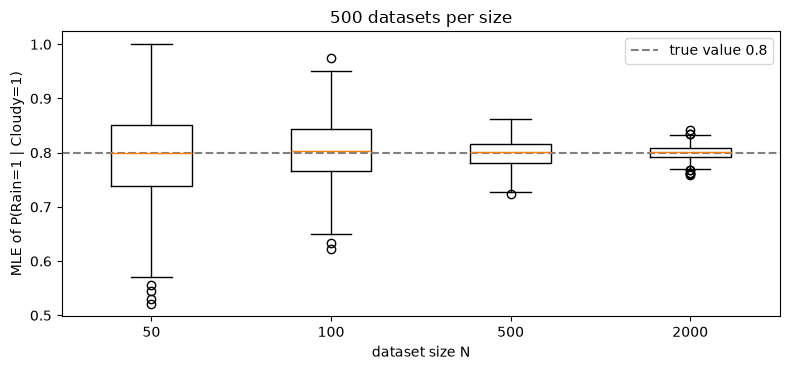

,N,mean estimate,std of estimate,theory sqrt(0.8*0.2/(N/2))
0,50,0.7941,0.0854,0.0800
1,100,0.8041,0.0570,0.0566
2,500,0.7997,0.0248,0.0253
3,2000,0.8002,0.0127,0.0126


In [27]:
spread = []
for n in [50, 100, 500, 2000]:
    ests = [rain_c1(fit(DiscreteMLE(), reference_model.simulate(n_samples=n, seed=1000 + s, show_progress=False)))
            for s in range(500)]
    spread.append({"N": n, "mean estimate": np.mean(ests), "std of estimate": np.std(ests),
                   "theory sqrt(0.8*0.2/(N/2))": np.sqrt(0.8 * 0.2 / (n / 2)), "_ests": ests})
spread_df = pd.DataFrame(spread)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.boxplot([row["_ests"] for row in spread], tick_labels=[str(r["N"]) for r in spread])
ax.axhline(0.8, ls="--", c="gray", label="true value 0.8")
ax.set(xlabel="dataset size N", ylabel="MLE of P(Rain=1 | Cloudy=1)", title="500 datasets per size")
ax.legend(); fig.tight_layout(); fig.savefig(OUT_DIR / "sampling_variability.png", dpi=150); plt.show()
spread_df.drop(columns="_ests").round(4)

In [28]:
VARIABILITY_PROMPT_TEMPLATE = r'''
I simulated five datasets of 100 samples each from the same Bayesian network (Cloudy -> Rain, Cloudy -> Sprinkler, Rain -> WetGrass, Sprinkler -> WetGrass), using random seeds 1 to 5. The true parameter is P(Rain=1 | Cloudy=1) = 0.8. For each dataset I fitted the CPTs by maximum likelihood with pgmpy and recorded the estimate of P(Rain=1 | Cloudy=1):

{table}

Explain why different datasets produce different estimates. Answer in a short paragraph; no code.
'''


table = "\n".join(f"seed {s}: estimate = {e:.4f}" for s, e in zip(five["seed"], five["estimate"]))
print(ask_coder(VARIABILITY_PROMPT_TEMPLATE.format(table=table), LARGE_MODEL))

[Qwen/Qwen2.5-Coder-32B-Instruct]

Different datasets produce different estimates because each dataset is a sample from the underlying Bayesian network and contains inherent randomness. The Maximum Likelihood Estimation (MLE) method calculates the parameters based on the observed frequencies in the data. Since each dataset is generated independently with a different random seed, they contain different samples, leading to variations in the observed frequencies of events like Rain given Cloudy. These variations result in different MLE estimates for the conditional probability P(Rain=1| Cloudy=1).


**Results.** With $N = 100$, the five estimates range from 0.694 to 0.796. All five fall *below* 0.8, which is simply chance in five draws. Each one is based on only the 44–56 rows with Cloudy = 1.

Over 500 datasets per size:
- the estimates are **centred on 0.8**, so the MLE is unbiased here;
- their standard deviation **shrinks like $1/\sqrt{N}$**, matching the binomial prediction $\sqrt{0.8 \cdot 0.2 / N_{C=1}}$ with $N_{C=1} \approx N/2$: about 0.057 at $N = 100$ and 0.013 at $N = 2000$.

**The LLM's explanation (Qwen2.5-Coder-32B)** is scientifically correct in substance. It attributes the differences to **sampling variability**: each dataset is a different random sample, so the observed frequencies, and therefore the MLEs, differ. It does not blame the LLM or pgmpy. It leaves out the two quantitative points above: that variability is governed by the number of Cloudy = 1 rows (about 50 here, not 100), and that it shrinks as $1/\sqrt{N}$. So it is a correct but qualitative account, and the measurement supplies the rest.

## 12. The lab's model run locally (as the lab notebook does)

All 12 prompts were replayed on **Qwen2.5-Coder-1.5B-Instruct loaded locally**, on an Apple-silicon Mac, using the lab's own setup: a `transformers` text-generation pipeline, `do_sample=False`, `max_new_tokens=1400`, and the lab's system prompt. The responses are in [`outputs/local_responses.json`](outputs/local_responses.json).

Every local response goes through **exactly the same checks** as the saved responses above: an identity comparison, the strict static check, execution, and validation against the trusted reference.

In [29]:
local = json.loads(pathlib.Path("outputs/local_responses.json").read_text())
print("local environment:", local["environment"])

variability_prompt = VARIABILITY_PROMPT_TEMPLATE.format(table=table)
TASKS = {  # prompt text -> (label, kind)
    INFERENCE_PROMPT: ("inference R1", "inference"), INFERENCE_FEEDBACK_PROMPT: ("inference R2", "inference"),
    INFERENCE_TEMPLATE_PROMPT: ("inference R3", "inference"),
    ESTIMATION_PROMPT: ("MLE R1", "mle"), ESTIMATION_FEEDBACK_PROMPT: ("MLE R2", "mle"),
    BAYESIAN_PROMPT: ("BDeu R1", "bdeu"), BAYESIAN_FEEDBACK_PROMPT: ("BDeu R2", "bdeu"),
    EXPLAIN_CPT_PROMPT: ("CPT explanation", "text"), variability_prompt: ("variability explanation", "text"),
    **{QUERY_PROMPT_TEMPLATE.format(query_text=q[0]): (f"query {q[0]}", ("query", q[1], q[2])) for q in QUERIES},
}
LAB_RECORDED = {INFERENCE_PROMPT: lab_recorded["inference"], ESTIMATION_PROMPT: lab_recorded["estimation"],
                BAYESIAN_PROMPT: lab_recorded["bayesian"]}


def assess(kind, response):
    # Same pipeline as Sections 5-9: strict check -> execute (unless unsafe) -> semantic validation.
    if kind == "text":
        return "–", "–"
    source = extract_python_code(response)
    problems = strict_generated_code_check(source, provided_inputs={"data", "model"})
    safety = [p for p in problems if p.startswith(SAFETY_MARKERS)]
    ns = {"data": data_1000.copy()}
    if isinstance(kind, tuple):
        ns["model"] = build_reference_model()
    if safety:
        return "; ".join(problems), "FAIL (blocked: " + "; ".join(safety) + ")"
    outcome = run_generated(source, ns)
    if outcome != "ran without error":
        return "; ".join(problems) or "none", f"FAIL ({outcome})"
    try:
        if kind == "inference":
            r = validate_generated_inference(ns)
            return "; ".join(problems) or "none", "PASS" if r["PASS"] else f"FAIL (runs, P(R=1|W=1)={r['posterior']:.4f})"
        if kind in ("mle", "bdeu"):
            name, trusted = ("generated_mle_model", trusted_mle) if kind == "mle" else ("generated_bayes_model", trusted_bdeu)
            r = validate_fit(ns, name, trusted)
            return "; ".join(problems) or "none", "PASS" if r["PASS"] else f"FAIL ({r})"
        _, var, evidence = kind
        value = float(ns["generated_result"].values[1])
        trusted = float(reference_infer.query([var], evidence=evidence, show_progress=False).values[1])
        return "; ".join(problems) or "none", "PASS" if np.isclose(value, trusted) else f"FAIL ({value:.4f} vs {trusted:.4f})"
    except Exception as e:
        return "; ".join(problems) or "none", f"FAIL (validation error: {type(e).__name__}: {e})"


saved_1p5 = {v["prompt"]: v["response"] for v in json.loads(CACHE_PATH.read_text()).values() if v["model"] == MAIN_MODEL}
rows = []
for r in local["responses"]:
    label, kind = TASKS[r["prompt"]]
    saved = saved_1p5.get(r["prompt"])
    local_problems, local_verdict = assess(kind, r["response"])
    saved_verdict = assess(kind, saved)[1] if saved else "(no saved 1.5B response)"
    rows.append({
        "task": label,
        "local = saved": saved is not None and saved.strip() == r["response"].strip(),
        "local = lab notebook": (LAB_RECORDED[r["prompt"]].strip() == r["response"].strip()) if r["prompt"] in LAB_RECORDED else "–",
        "similarity to saved": round(difflib.SequenceMatcher(None, saved or "", r["response"]).ratio(), 2) if saved else None,
        "local verdict": local_verdict,
        "saved verdict": saved_verdict,
        "local seconds": r["seconds"],
    })
order = list(dict.fromkeys(label for label, _ in TASKS.values()))
local_table = pd.DataFrame(rows).set_index("task").loc[[t for t in order if t in {r["task"] for r in rows}]]
local_table

local environment: {'python': '3.11.11', 'platform': 'macOS-27.0-arm64-arm-64bit', 'torch': '2.14.0', 'transformers': '5.17.0', 'cuda': None, 'mps': True}
+--------------+------------------+
| Sprinkler    |   phi(Sprinkler) |
+==============+==================+
| Sprinkler(0) |           0.5722 |
+--------------+------------------+
| Sprinkler(1) |           0.4278 |
+--------------+------------------+


,local = saved,local = lab notebook,similarity to saved,local verdict,saved verdict,local seconds
task,,,,,,
inference R1,False,True,0.68,FAIL (ImportError: cannot import name 'BayesianModel' from 'pgmpy.models'),FAIL (ImportError: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.),42.2
inference R2,False,–,0.69,FAIL (ValueError: Length of evidence_card doesn't match length of evidence),FAIL (AttributeError: 'list' object has no attribute 'shape'),40.7
inference R3,False,–,0.17,FAIL (TypeError: unsupported operand type(s) for -: 'int' and 'list'),FAIL (AttributeError: 'list' object has no attribute 'shape'),31.5
MLE R1,False,False,0.60,FAIL (ImportError: cannot import name 'BayesianModel' from 'pgmpy.models'),FAIL (NameError: name 'pd' is not defined),23.5
MLE R2,False,–,0.78,PASS,PASS,19.7
BDeu R1,False,True,0.34,FAIL (blocked: Forbidden attribute call: .read_csv(...)),FAIL (ImportError: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.),20.9
BDeu R2,False,–,0.72,FAIL (blocked: Forbidden attribute call: .read_csv(...)),PASS,14.5
CPT explanation,False,–,0.10,–,–,16.3
variability explanation,False,–,NaN,–,(no saved 1.5B response),18.0


In [30]:
for r in local["responses"]:
    label, kind = TASKS[r["prompt"]]
    if kind == "text" or isinstance(kind, tuple):
        print(f"==== local response: {label} ====\n{r['response']}\n")

==== local response: query P(Cloudy | WetGrass=1) ====
```python
from pgmpy import BayesianModel
from pgmpy.inference import VariableElimination

# Assuming 'model' is already defined as per the problem statement
model = BayesianModel([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Create a VariableElimination object
ve = VariableElimination(model)

# Compute P(Cloudy | WetGrass=1)
generated_result = ve.query(variables=['Cloudy'], evidence={'WetGrass': 1})

print(generated_result)
```

This code snippet uses the `VariableElimination` class from the `pgmpy.inference` module to compute the conditional probability P(Cloudy | WetGrass=1) given the model and evidence. The result is stored in the `generated_result` variable, which can be printed or further processed as needed.

==== local response: query P(Rain | WetGrass=1, Sprinkler=0) ====
```python
from pgmpy.models import BayesianModel
from pgmpy.inference import VariableElimination

# 

### What the local run shows

**1. Local runs reproduce each other; the hosted responses were the ones that drifted.** Two of the three original prompts (inference and BDeu round 1) produced **exactly** the same text locally as in the lab notebook's own recorded run. The third, MLE, differed: the lab ran in Colab on a GPU, while this run used an Apple GPU (MPS), a different numerical backend. **None** of the 12 local responses exactly matches its saved hosted response, and similarity ranges from 0.10 to 0.78. The prompts, the model and greedy decoding were identical. The serving setup is what changed the output.

**2. It does not change the headline conclusions, but it removes three of the model's apparent successes.**

| Code task | Local run | Saved (hosted) run |
|---|---|---|
| Inference, rounds 1–3 | all fail | all fail |
| MLE, round 1 → round 2 | fail → **pass** | fail → **pass** |
| BDeu, round 1 → round 2 | fail → **fail** | fail → pass |
| The three HW queries | **0 / 3** | 1 / 1 (the others were only asked of 32B) |
| **Total passing** | **1 of 10** | **3 of 8** |

- **MLE round 2 passes in both runs.** It is the only result that holds in both, so "concrete feedback fixed the estimation code" is robust for MLE.
- **BDeu round 2 fails locally.** It *still* calls `pd.read_csv('your_data.csv')`, although the feedback prompt's first point says exactly not to do that. The strict check blocks it. The hosted run's success on this task was one lucky sample, not a reliable property of the model.
- **All three queries fail locally**, in the same way, and for a reason worse than an API error:
  - the code imports `BayesianModel`, a class that has been removed (from `pgmpy.models`, and in two cases from top-level `pgmpy`, where it never existed);
  - it then **overwrites the validated `model` it was given** with a bare structure that has no CPDs, directly violating "Do not rebuild or modify the model".

  Even with a working import, the query would have run on an empty network. The hosted 1.5B's correct answer to the first query did not generalise.
- **Inference fails in every round, in both runs**, as before. Locally, round 2 fails at `evidence_card=[2]` for two parents (a `ValueError` with a clear message), and round 3 fails when the template is misapplied (`1 - p` on a list).

**3. The explanations are different, and neither is right.**
- **CPT explanation.** The local answer gets the **column order right**, $(R,S) = (0,0), (0,1), (1,0), (1,1)$, which is better than the hosted 1.5B answer. But it says each column "corresponds to the probability that WetGrass is 0". A column holds the *whole* distribution $P(W \mid R, S)$ (row 0 **and** row 1), so it is half right.
- **Variability explanation.** The local answer correctly blames the random sampling and the small sample size. It also claims the "simulations are not perfectly replicable due to the randomness involved", which is false: a seeded simulation is exactly replicable. The estimates differ because the *seeds* differ.

**4. Cost.** Each local response took **15–42 s** on an Apple GPU. Inference prompts were the slowest, because they produce the longest programs.

**Answer to "could running through an API have caused the errors?":** no. The same model run locally, exactly as the lab does, made **every category of error** seen through the API: removed classes, wrong CPT layouts, invented data, forbidden file reads. It passed *fewer* tasks (1 of 10). The serving path changed *which* wrong program came out, not *whether* it was wrong. The errors belong to the model.

## 13. What failed, the rubric, and what the LLM contributed

### The lab's list of potential failure modes: which ones actually happened

| Failure mode (from the lab) | Observed here? | Where |
|---|---|---|
| Ambiguous natural-language specification | **yes** | the prompt says "use MaximumLikelihoodEstimator" but not which calling convention or library version; models chose APIs that the installed pgmpy rejects |
| The LLM uses an obsolete API | **yes, in every model** | `BayesianModel`, `BayesianNetwork`, `model.query`, `model.fit(estimator_object)`, `fit(..., estimator=MaximumLikelihoodEstimator)` |
| The LLM reverses a CPT row or parent ordering | **yes** | 1.5B: Rain rows reversed, WetGrass rows swapped, and CPD parents never declared; 32B: WetGrass rows swapped; Qwen3-30B: Sprinkler table scrambled |
| Generated code imports or calls something unintended | **yes** | `pd.read_csv('your_data.csv')` despite "do not read files", missed by the lab's AST check |
| Code executes but represents the wrong distribution | **yes** | 32B and Qwen3-30B inference programs: they run and pass `check_model()`, with the wrong posterior |
| Inference query uses the wrong evidence state | no | all generated queries used the correct evidence; locally, however, they overwrote the provided model (Section 12) |
| Dataset uses a different state encoding from the model | no, but a near miss | the generated estimation code *replaced* the dataset with invented rows |
| Sparse data make estimates unstable | **yes (by design)** | $N = 100$: estimates from 0.69 to 0.80; standard deviation 0.057 |
| A prior introduced without being documented | no | the Bayesian fit's prior was verified explicitly (it differs from MLE and from ESS = 50) |
| A validation test checks syntax and misses semantics | **yes** | `check_model()` accepted two wrong models; only the joint and posterior tests caught them |

### Rubric scorecard for the Qwen2.5-Coder-1.5B programs

| Rubric item | Inference R1 | Inference R2 | Inference R3 | Estimation R1 | Estimation R2 | Bayesian R1 | Bayesian R2 |
|---|---|---|---|---|---|---|---|
| Correct variables and edges | ✓ | ✗ (no edges) | ✓ | ✓ | ✓ | ✓ (new) / ✗ (lab) | ✓ |
| CPDs normalised | ✗ | ✗ | ✗ | – | ✓ | – | ✓ |
| Evidence variables and parent ordering | ✗ | ✗ | ✗ | – | ✓ | – | ✓ |
| Probabilities match the specification | ✗ | ✗ | ✗ | – | – | – | – |
| Correct query and evidence | ✗ | ✓ | ✗ | – | – | – | – |
| Posterior / fit agrees with trusted | ✗ | ✗ | ✗ | ✗ | ✓ | ✗ | ✓ |
| Graph not relearned; requested estimator used | – | – | – | ✗ | ✓ | ✗ | ✓ |
| Prior explicit and verified | – | – | – | – | – | ✗ | ✓ |
| No file, network or system access | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ (new) / **✗ read_csv** (lab) | ✓ |
| Uses the provided data | – | – | – | **✗ invents data** | ✓ | ✗ (lab) | ✓ |
| Runs on the installed pgmpy | ✗ | ✗ | ✗ | ✗ | ✓ | ✗ | ✓ |

### What exactly did the LLM contribute?

- **What it gave:** a correct *skeleton* for every task, plus a usable MLE program after one round of concrete feedback, in both the hosted and the local run. BDeu feedback worked in the hosted run only. For the three new queries, Qwen2.5-Coder-32B produced correct one-line inference calls immediately; the 1.5B model did so once (hosted) and never when run locally. The larger model gave a correct explanation of the CPT convention and a correct (if qualitative) account of sampling variability.
- **What it did not give:** a single correct probability table, from any model at any size. It gave no program that ran on the installed library from the lab's original prompts, and no awareness of the installed library version. It also produced one violation of an explicit safety constraint (`read_csv`).
- **What the human and the tools did:**
  - wrote the trusted reference and the enumeration oracle;
  - found that the lab's safety check misses attribute calls;
  - turned every failure into concrete feedback;
  - decided when to stop prompting and fix by hand;
  - validated semantically (the joint distribution and posteriors, not just `check_model()`);
  - noticed that the "deterministic" greedy decoding did not reproduce the lab's recorded responses through the hosted model, while the local run reproduced two of them exactly.

`pgmpy` did all the probabilistic computation. The LLM never computed a probability.

The lab's central claim held up in every experiment:
$$\text{program runs} \;\neq\; \text{probabilistic model is correct} \;\neq\; \text{scientific assumptions are appropriate}.$$